In [9]:
import psycopg as pg
import pandas as pd
import os
import mlflow
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from category_encoders import CatBoostEncoder
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import (
    OneHotEncoder, 
    SplineTransformer, 
    QuantileTransformer, 
    RobustScaler,
    PolynomialFeatures,
    KBinsDiscretizer,
)
import autofeat
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

In [3]:
TABLE_NAME = "users_churn" # таблица с данными в postgres 

TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

ASSETS_DIR = "assets"

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

os.makedirs(ASSETS_DIR, exist_ok=True)

pd.options.display.max_columns = 100
pd.options.display.max_rows = 64

In [4]:
# определяем основные credentials, которые нужны для подключения к MLflow
# важно, что credentials мы передаём для себя как пользователей Tracking Service
# у вас должен быть доступ к бакету, в который вы будете складывать артефакты
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net" #endpoint бакета от YandexCloud
os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID") # получаем id ключа бакета, к которому подключён MLFlow, из .env
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY") # получаем ключ бакета, к которому подключён MLFlow, из .env
# определяем глобальные переменные
# поднимаем MLflow локально
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

EXPERIMENT_NAME = "churn_vds"
RUN_NAME = "feature_selection"
# REGISTRY_MODEL_NAME = "afc_transformer"
FS_ASSETS = "fs_assets" 

In [5]:
connection = {"sslmode": "require", "target_session_attrs": "read-write"}
postgres_credentials = {
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

connection.update(postgres_credentials)

# определим название таблицы, в которой хранятся наши данные.
TABLE_NAME = "users_churn"

# эта конструкция создаёт контекстное управление для соединения с базой данных 
# оператор with гарантирует, что соединение будет корректно закрыто после выполнения всех операций 
# закрыто оно будет даже в случае ошибки, чтобы не допустить "утечку памяти"
with pg.connect(**connection) as conn:

# создаёт объект курсора для выполнения запросов к базе данных
# с помощью метода execute() выполняется SQL-запрос для выборки данных из таблицы TABLE_NAME
    with conn.cursor() as cur:
        cur.execute(f"SELECT * FROM {TABLE_NAME}")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

cat_features = [
    'paperless_billing',
    'payment_method',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'tech_support',
    'streaming_tv',
    'streaming_movies',
    'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'multiple_lines',
]
num_features = ["monthly_charges", "total_charges"]
features = cat_features + num_features
df = pd.DataFrame(data, columns=columns).dropna(subset=features)

In [6]:
split_column = "begin_date"
test_size = 0.2

df = df.sort_values(by=[split_column])

X_train, X_test, y_train, y_test = train_test_split(
    df[features],
    df['target'],
    test_size=test_size,
    shuffle=False,
) 

In [10]:
transformations = ('1/', 'log', 'abs', 'sqrt')

afc = autofeat.AutoFeatClassifier(categorical_cols=cat_features, transformations=transformations, feateng_steps=1, n_jobs=-1)

X_train_features = afc.fit_transform(X_train, y_train)
X_test_features = afc.transform(X_test)

In [12]:
estimator = RandomForestClassifier(n_estimators=30)
sfs = SFS(estimator, k_features=10, forward=True, floating=False, scoring='roc_auc', cv=4, n_jobs=-1)
sbs = SFS(estimator, k_features=10, forward=False, floating=False, scoring='roc_auc', cv=4, n_jobs=-1)

sfs = sfs.fit(X_train_features, y_train)
sbs = sbs.fit(X_train_features, y_train)

top_sfs = sfs.k_feature_names_
top_sbs = sbs.k_feature_names_

print('\nSequential Forward Selection (k=10)')
print('CV Score:')
print(sfs.k_score_)

print('\nSequential Backward Selection')
print('CV Score:')
print(sbs.k_score_)

/home/mle-user/mle_projects/mle-mlflow/.venv_mlflow/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
/home/mle-user/mle_projects/mle-mlflow/.venv_mlflow/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
/home/mle-user/mle_projects/mle-mlflow/.venv_mlflow/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
/home/mle-user/mle_projects/mle-mlflow/.venv_mlflow/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params


Sequential Forward Selection (k=10)
CV Score:
0.7619001860700249

Sequential Backward Selection
CV Score:
0.72558394520984


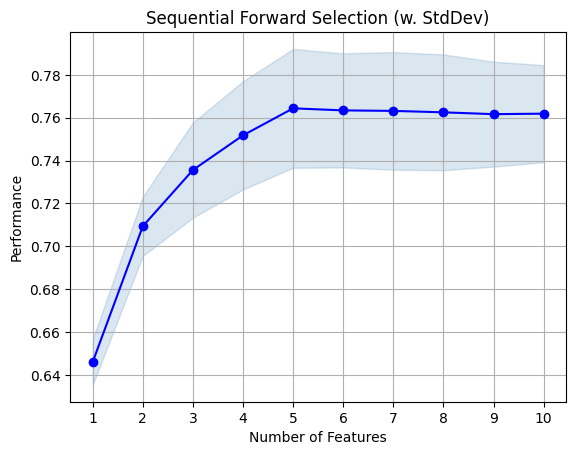

<Figure size 640x480 with 0 Axes>

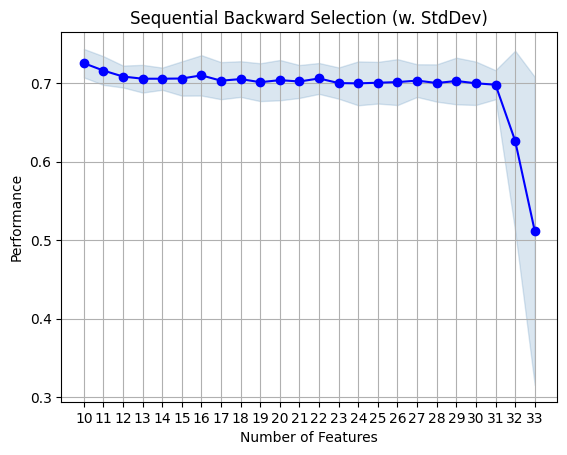

<Figure size 640x480 with 0 Axes>

In [13]:
sfs_df = pd.DataFrame.from_dict(sfs.get_metric_dict()).T
sbs_df = pd.DataFrame.from_dict(sbs.get_metric_dict()).T 

os.mkdir(FS_ASSETS)

sfs_df.to_csv(f"{FS_ASSETS}/sfs.csv")
sbs_df.to_csv(f"{FS_ASSETS}/sbs.csv") 

fig = plot_sfs(sfs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Forward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig(f"{FS_ASSETS}/sfs.png") 

fig = plot_sfs(sbs.get_metric_dict(), kind='std_dev')

plt.title('Sequential Backward Selection (w. StdDev)')
plt.grid()
plt.show()

plt.savefig(f"{FS_ASSETS}/sbs.png") 

In [14]:
experiment_id = mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

with mlflow.start_run(run_name=f"{RUN_NAME}_intersection_and_union", experiment_id=experiment_id) as run:
    run_id = run.info.run_id
   
    mlflow.log_artifacts(FS_ASSETS) 
print(run_id)

2026-04-22 22:54:00,615 INFO: Found credentials in environment variables.


d2c0d380a599418b9714773a58c74377


In [15]:
interc_features = list(set(top_sbs) & set(top_sfs))
union_features = list(set(top_sbs) | set(top_sfs))

In [23]:
model = CatBoostClassifier(auto_class_weights='Balanced', verbose=False).fit(X_train_features[interc_features], y_train) 
roc_auc_score(y_test, model.predict_proba(X_test_features[interc_features])[:,1])

0.685325373917607

In [24]:
REGISTRY_MODEL_NAME = "churn_model_vds"
EXPERIMENT_NAME = 'feature_selection_intersection'
experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
with mlflow.start_run(run_name='model_sfs_interc', experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    # ваш код здесь
    model_info = mlflow.sklearn.log_model( 
            sk_model=model,
            artifact_path='models',
            registered_model_name=REGISTRY_MODEL_NAME,
		)

Registered model 'churn_model_vds' already exists. Creating a new version of this model...
2026/04/22 23:01:44 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: churn_model_vds, version 7
Created version '7' of model 'churn_model_vds'.


In [ ]:
run_id

'024fc905984c4cb38dea31cec9472c5c'

In [26]:
model = CatBoostClassifier(auto_class_weights='Balanced', verbose=False).fit(X_train_features[union_features], y_train) 
roc_auc_score(y_test, model.predict_proba(X_test_features[union_features])[:,1])

0.6464423161025102

In [27]:
REGISTRY_MODEL_NAME = "churn_model_vds"
EXPERIMENT_NAME = 'feature_selection_union'
experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
with mlflow.start_run(run_name='model_sfs_union', experiment_id=experiment_id) as run:
    run_id = run.info.run_id
    # ваш код здесь
    model_info = mlflow.sklearn.log_model( 
            sk_model=model,
            artifact_path='models',
            registered_model_name=REGISTRY_MODEL_NAME,
		)

Registered model 'churn_model_vds' already exists. Creating a new version of this model...
2026/04/22 23:02:07 INFO mlflow.tracking._model_registry.client: Waiting up to 300 seconds for model version to finish creation. Model name: churn_model_vds, version 8
Created version '8' of model 'churn_model_vds'.


In [29]:
run_id

'024fc905984c4cb38dea31cec9472c5c'